## gif making code generated in chat gpt

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import geopandas as gpd
import matplotlib.patches as patches


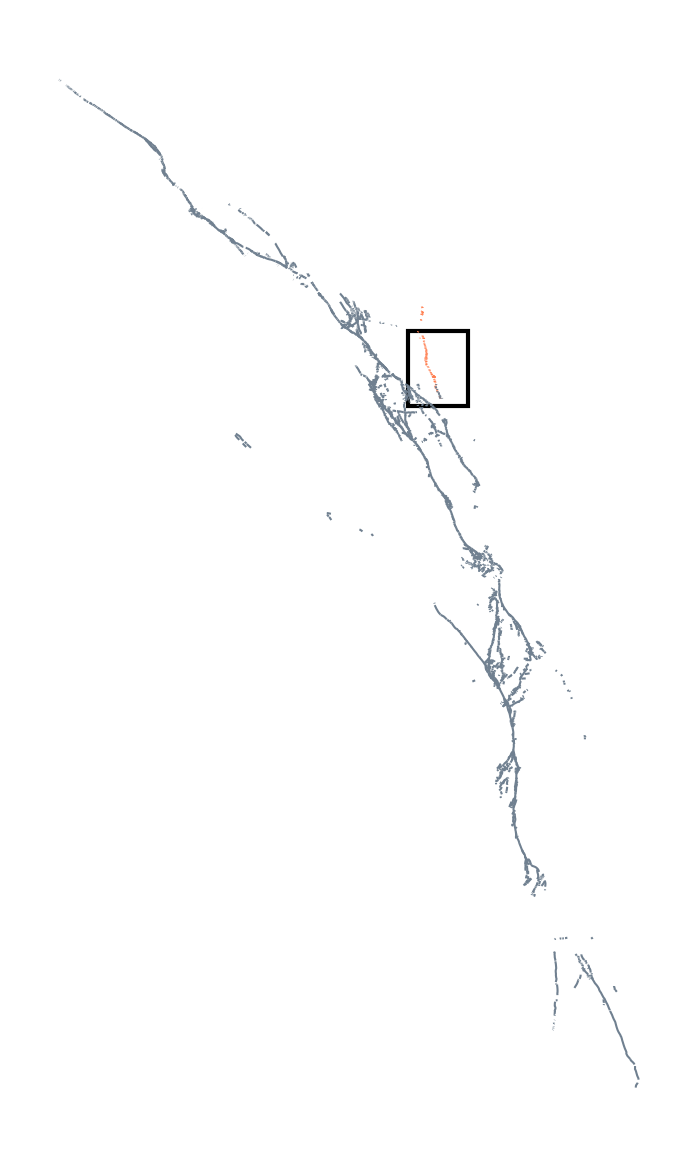

In [121]:
galway = gpd.read_file("kmz/GalwayLake_distributed.shp")
landers = gpd.read_file("kmz/Landers_distributed.shp")

# Plot
fig, ax = plt.subplots(dpi=300)
galway.plot(ax=ax, color='coral',lw=0.5)
landers.plot(ax=ax, color='slategray',lw=0.5)

ax.set_aspect('equal')

rect = patches.Rectangle(
    (-116.51, 34.485),  # Bottom-left corner (Longitude, Latitude)
    0.04,              # Width (Longitude span)
    0.05,              # Height (Latitude span)
    linewidth=1,       # Line width of the rectangle
    edgecolor='black', # Rectangle color
    facecolor='none'   # No fill color
)
ax.add_patch(rect)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.savefig('ref_map_L_GL.png')

In [122]:

def get_lines_from_shapefile(shapefile_path):
    gdf = gpd.read_file(shapefile_path)
    lines = []

    for geom in gdf.geometry:
        if geom.type == 'LineString':
            lines.append(list(geom.coords))
        elif geom.type == 'MultiLineString':
            for part in geom.geoms:
                lines.append(list(part.coords))
    return lines

def plot_shapefile_lines(lines, ax, color):
    for line in lines:
        lon_lat_pairs = [(pt[0], pt[1]) for pt in line]
        lons, lats = zip(*lon_lat_pairs)
        ax.plot(lons, lats, color=color, lw=1)

def plot_map_with_box(galway_shp, landers_shp, output_file):
    galway_lines = get_lines_from_shapefile(galway_shp)
    landers_lines = get_lines_from_shapefile(landers_shp)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # Plot the full shapefiles
    plot_shapefile_lines(galway_lines, ax, color='coral')
    plot_shapefile_lines(landers_lines, ax, color='dimgray')

    # Add the black rectangle outlining the GIF area
    rect = patches.Rectangle(
        (-116.51, 34.47),  # Bottom-left corner (Longitude, Latitude)
        0.03,              # Width (Longitude span)
        0.11,              # Height (Latitude span)
        linewidth=1,       # Line width of the rectangle
        edgecolor='black', # Rectangle color
        facecolor='none'   # No fill color
    )
    ax.add_patch(rect)

    # Set map limits to show full shapefiles while keeping the GIF region visible
    ax.set_xlim([-116.6, -116.4])  # Broader longitude range
    ax.set_ylim([34.4, 34.6])       # Broader latitude range

    # Remove axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')

    # Set the title
    ax.set_title('Full Shapefiles with Outlined Area')

    # Save the figure as a PNG
    plt.savefig(output_file, dpi=300)
    plt.close(fig)

def make_gif_from_shapefiles(galway_shp, landers_shp, gif_filename):
    galway_lines = get_lines_from_shapefile(galway_shp)
    landers_lines = get_lines_from_shapefile(landers_shp)
    frames = []

    def create_frame(g_lines=None, l_lines=None, title=''):
        fig, ax = plt.subplots(dpi=300)
        if g_lines:
            plot_shapefile_lines(g_lines, ax, color='coral')
        if l_lines:
            plot_shapefile_lines(l_lines, ax, color='dimgray')
        ax.set_xlim([-116.51, -116.48])
        ax.set_ylim([34.485, 34.51])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_aspect('equal')
        ax.set_title(title)

        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        plt.close(fig)
        return frame

    # Frame 1: Galway only
    frames.append(create_frame(g_lines=galway_lines, title='Galway Lake'))

    # Frame 2: Landers only (always dimgray)
    frames.append(create_frame(l_lines=landers_lines, title='Landers'))

    # Frame 3: Both
    frames.append(create_frame(g_lines=galway_lines, l_lines=landers_lines, title='Both Events'))

    # Save GIF (set durations for each frame)
    imageio.mimsave(gif_filename, frames, duration=[1500, 1500, 3500],loop=True)


In [123]:
make_gif_from_shapefiles('kmz/GalwayLake_distributed.shp', 'kmz/Landers_distributed.shp', 'galway_landers.gif')

/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_78226/1804614998.py:6: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_78226/1804614998.py:79: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')


In [124]:
plot_map_with_box(
    'kmz/GalwayLake_distributed.shp',
    'kmz/Landers_distributed.shp',
    'full_shapefiles_map.png'
)

/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_78226/1804614998.py:6: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':


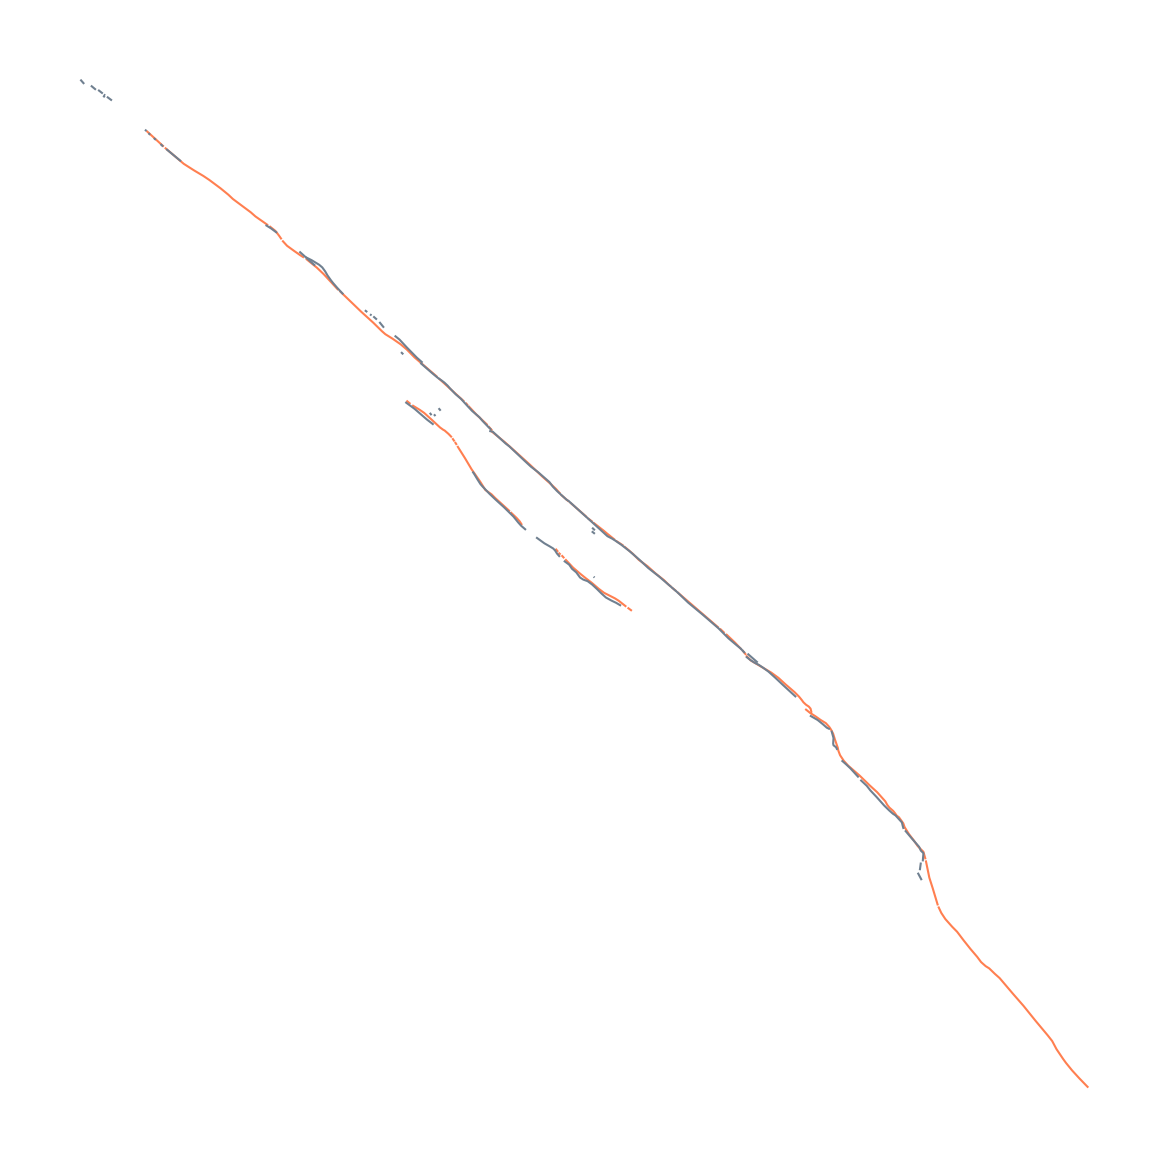

In [125]:
P66 = gpd.read_file("kmz/Parkfield1966_distributed.shp")
P04 = gpd.read_file("kmz/Parkfield2004_distributed.shp")

fig, ax = plt.subplots(dpi=300)
P66.plot(ax=ax, color='coral',lw=0.5)
P04.plot(ax=ax, color='slategray',lw=0.5)

ax.set_aspect('equal')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.savefig('ref_map_P66_P04.png')

In [126]:
import geopandas as gpd
import matplotlib.pyplot as plt
import imageio
import numpy as np

# Read shapefiles
P66 = gpd.read_file("kmz/Parkfield1966_distributed.shp")
P04 = gpd.read_file("kmz/Parkfield2004_distributed.shp")

# Function to plot shapefile lines with a given color
def plot_shapefile_lines(lines, ax, color):
    for line in lines:
        lon_lat_pairs = [(pt[0], pt[1]) for pt in line]
        lons, lats = zip(*lon_lat_pairs)
        ax.plot(lons, lats, color=color, lw=0.5)

# Function to extract lines from shapefiles
def get_lines_from_shapefile(shapefile):
    lines = []
    for geom in shapefile.geometry:
        if geom.type == 'LineString':
            lines.append(list(geom.coords))
        elif geom.type == 'MultiLineString':
            for part in geom.geoms:
                lines.append(list(part.coords))
    return lines

# Create frames for GIF
def create_frame(P66_lines=None, P04_lines=None, title=''):
    fig, ax = plt.subplots(dpi=300)
    
    # Plot Parkfield 1966 (P66) in coral
    if P66_lines:
        plot_shapefile_lines(P66_lines, ax, color='coral')  # Ensure coral color
    
    # Plot Parkfield 2004 (P04) in dimgray
    if P04_lines:
        plot_shapefile_lines(P04_lines, ax, color='dimgray')  # Ensure dimgray color
    
    ax.set_aspect('equal')
    
    # Remove spines and ticks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Title and frame update
    ax.set_title(title)
    
    # Create frame
    fig.canvas.draw()
    frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    return frame

# Get lines from shapefiles
P66_lines = get_lines_from_shapefile(P66)
P04_lines = get_lines_from_shapefile(P04)

# Create frames for GIF
frames = []

# Frame 1: Parkfield 1966 (P66) in coral
frames.append(create_frame(P66_lines, title='Parkfield 1966'))

# Frame 2: Parkfield 2004 (P04) in dimgray
frames.append(create_frame(P04_lines, title='Parkfield 2004'))

# Frame 3: Both Parkfield 1966 and 2004, P66 in coral and P04 in dimgray
frames.append(create_frame(P66_lines, P04_lines, title='Parkfield 1966 & 2004'))

# Save the GIF with a duration for each frame
imageio.mimsave('parkfield_1966_2004.gif', frames, duration=[1500, 1500, 3000],loop=True)


/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_78226/811151415.py:21: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_78226/811151415.py:55: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_78226/811151415.py:55: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_78226/811151415.py:55: MatplotlibDeprecationWarning: The tostring_